# ITCS 6169/8169 — Computer Vision
## Assignment 1: The CNN Challenge
**Due: September 25, 2026 at 11:59 PM EDT**

---

In this assignment, you will build and train a convolutional neural network (CNN) for **16-class scene recognition** using a small dataset of **2,400 training images**.

This notebook is intentionally only a **starter baseline**. It provides a clean training pipeline and a deliberately simple CNN. Your task is to improve the system through informed decisions about architecture, optimization, augmentation, regularization, model selection, and training strategy.

### 2026 workflow: AI is your pair programmer
Use of an AI coding assistant (e.g., ChatGPT, Codex, GitHub Copilot, Claude Code, Gemini, Cursor) is **required**. You may use AI to help implement, debug, refactor, explain, or suggest experiments. However, **you are responsible for the scientific decisions and for verifying all generated code**.

Your final GitHub repository must include an `AI_USAGE.md` file describing representative AI-assisted tasks, at least one incorrect/ineffective AI suggestion, how you verified or corrected it, and one important decision that you made yourself.

### Important model restriction
The primary classifier for Assignment 1 must be a **CNN**. Do **not** use CLIP, DINO/DINOv2, VLM APIs, Vision Transformers as the primary model, or other foundation-model embeddings for your main submission. Pretrained CNNs are allowed if clearly documented.

### Google Colab
Google Colab is recommended, but not required. If using Colab, enable a GPU through **Runtime → Change runtime type → GPU**. You may also use the Educational Cluster or another resource for which you have authorized access.

In [12]:
# The follwowing was for debugging my current kernal and adding the needed deps the notebook
print("Test")
import sys
print(sys.executable)

import numpy as np
print(np.__version__)

# This is debugging making sure that the file strcuture is correct
import os
print(os.getcwd())
print(os.listdir())


# This is debugging switching from CPU to GPU
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

    

Test
/home/ward/MainDir/ComputerVision/CNN/CNNvenv/bin/python
2.5.3
/home/ward/MainDir/ComputerVision/CNN
['ITCS_6169:8169_Assignment1.pdf', 'ITCS_6169_8169_Assignment1_2026_Starter.ipynb', 'CNNvenv', '.ipynb_checkpoints', '.requirements.txt', '.git', 'data', '.gitignore', 'AI_Usage.md', 'README.md']
True
NVIDIA GeForce GTX 1660 Ti


In [13]:
# Core imports
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.14.0+cu130
CUDA available: True


In [14]:
# Optional: mount Google Drive when running in Colab.
# Skip this cell if you are running locally or on another server.
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
except ImportError:
    print("Not running in Google Colab; Drive mount skipped.")

Not running in Google Colab; Drive mount skipped.


## 1. Set your working directory

Download the assignment dataset from the link provided in the assignment handout and organize it so that the notebook can find:

```text
data/
  train/
    class_1/
    ...
  test/
    class_1/
    ...
```

If you use Google Drive, change `PROJECT_ROOT` below to your assignment folder. **Do not hard-code a TA/instructor solution path.**

In [15]:
# CHANGE THIS PATH to your own assignment directory.
# Example for Colab + Google Drive:
# PROJECT_ROOT = Path('/content/gdrive/MyDrive/ITCS_6169_8169/assignment1')

PROJECT_ROOT = Path('.')
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'

print('Project root:', PROJECT_ROOT.resolve())
print('Training data:', TRAIN_ROOT)
print('Testing data:', TEST_ROOT)

Project root: /home/ward/MainDir/ComputerVision/CNN
Training data: data/train
Testing data: data/test


## 2. Reproducibility and device

A fixed seed makes the starter result easier to reproduce. Exact GPU reproducibility is not always guaranteed across hardware/software versions, so report your environment and seed in the final repository.

In [16]:
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 3. Loading and preprocessing the data

The starter baseline converts images to grayscale and resizes them to $64\times64$. This is **not necessarily a good final choice**. You should decide whether color, resolution, normalization, and augmentation should be changed.

We split the provided training data into **training and validation sets**. Use the validation set for architecture/hyperparameter decisions. **Do not repeatedly tune on the test set.** The test set should be used for the final evaluation of a selected model.

In [32]:
IMG_SIZE = 128
BATCH_SIZE = 64
VAL_FRACTION = 0.20

######################################
# Data TrAnsforms
######################################
from torchvision.transforms import v2

######################################################################
# vldation and test data set
baseline_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

######################################################################
# Deliberately simple preprocessing for the starter baseline.
# TODO: improve this as part of your experiments.
easy_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.4,
    ),
    
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

###################################################################
medium_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomSolarize(.5, .4),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
    ),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=5
    ),
    transforms.RandomHorizontalFlip(p=.5),
    transforms.ToTensor(),

    transforms.Normalize(mean=[0.5], std=[0.5]),

])

#######################################################################
hard_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.6
    ),
    transforms.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(.8, 1.0)
    ),
    transforms.RandomVerticalFlip(.5),
    transforms.RandomHorizontalFlip(p=.5),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.7,
        scale=(0.1, 0.30),
        ratio=(1, 1)
    ),
     transforms.RandomSolarize(.9, .4),
     # transforms.ColorJitter(
    #     brightness=0.5,
    #     contrast=0.5,
    # ),

    transforms.Normalize(mean=[0.5], std=[0.5]),

])
###################################################################################
# in training transforms already set so we then use this here to visualize
# options include:
# - easy_transform
# - medium_transform
# - hard_transform
# - baseline_transform

transform_to_visualize = easy_transform
##################################################################################
# aplies the baseline transformssuch as resizing and to Tensor
full_train_dataset = datasets.ImageFolder(TRAIN_ROOT, transform=baseline_transform)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=baseline_transform)


class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')
print(f'Total training images: {len(full_train_dataset)}')
print(f'Test images: {len(test_dataset)}')

# Establishes data set sizes
val_size = int(round(len(full_train_dataset) * VAL_FRACTION))
train_size = len(full_train_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)


# Data set split 
# train_dataset, val_dataset = random_split(
#     full_train_dataset, [train_size, val_size], generator=generator
# )


# Step1: First determine the split
train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)


# Step2: Separate the underlying datasets
train_full = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=transform_to_visualize
)

val_full = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=baseline_transform
)


# Step3: Keep the original split by only selcting the overlapping from rand split
train_dataset = torch.utils.data.Subset(
    train_full,
    train_subset.indices
)

val_dataset = torch.utils.data.Subset(
    val_full,
    val_subset.indices
)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

print(f'Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Total training images: 2400
Test images: 400
Train: 1920 | Validation: 480 | Test: 400


## Visualize different layers

In the above code there is a var named transform_to_visualize which you can set to visualize a transform. Options for teh var can be see in the comments surrounding teh var. To Visualize the Images, shift run both the above and below blocks.

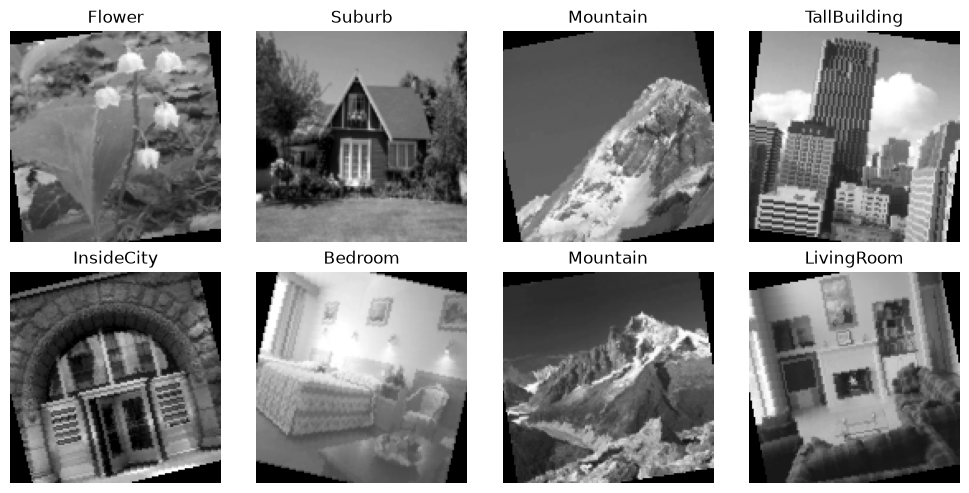

In [33]:
# Visualize a few training examples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    image = image * 0.5 + 0.5  # unnormalize
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Training a CNN from scratch

Gone are the days when hand-designed features were the default solution. We will start with end-to-end learning and train a CNN directly for 16-way classification.

The architecture below is deliberately weak and simple. **Do not treat it as a recommended architecture.** It exists only to verify that the pipeline works and to give you a baseline to beat.

In [34]:
class TNet(nn.Module):
    """A deliberately small CNN starter baseline."""
    def __init__(self, num_classes=16):
        super().__init__()
        
        #Defines the features in order of layer 1, layer, etc 
        self.features = nn.Sequential(
            
            # starts with one Cnn layer of 1 channel, 16 filters, filters of size 3x3
            # We add additional layers to try and learn the features better and in more
            # significant ways as we continue
            # padding helps prevent some of the spatial dimensions from reducing
            nn.Conv2d(1,16, kernel_size=3, padding=1),
            nn.Conv2d(16,32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32,32, kernel_size=3, padding=1),
            nn.Conv2d(32,32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # drop 20% of activations makes it harder to memorize teh answers
            # nn.Dropout2d(p=0.1),
            
            # nn.Conv2d(64, 128, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
        )
        self.classifier = nn.Sequential(
            
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            # nn.Linear(16 * 15 * 15, num_classes),
            nn.Linear(16, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TNet(num_classes=num_classes)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

TNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stri

## ResNet Weight Initilization and Transform

In [29]:
# ResNet BackBone
NUM_WORKERS = 4

from torchvision.models import resnet18, ResNet18_Weights

# grabs resnet weights
weights = ResNet18_Weights.DEFAULT

# init resnet with said weights
teacher = resnet18(weights=weights)

# create a dup conv
old_conv = teacher.conv1

# create a one channel resnet
new_conv = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# now converge the weights from old conv back into the new conv var
with torch.no_grad():
    new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

# conv1 in teacher updated
teacher.conv1 = new_conv


num_features = teacher.fc.in_features

# Creates a fully connected linear layer between the last layer in resnet and our classes
teacher.fc = nn.Linear(
    num_features,
    num_classes
)


# Teacher Transform / Image Augmentation
teacher_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

# Creates the teacher data set and filters off same split as teh CNN Model
teacher_full = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=teacher_transform
)

teacher_dataset = torch.utils.data.Subset(
    teacher_full,
    train_subset.indices
)

# allows teacher and student to see teh same training examples
teacher_loader = DataLoader(
    teacher_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

## ResNet Training Method

In [22]:
# Trains Resnet using the inputted fields
def train_ResNet(teacher, teacher_optimizer, teacher_criterion, teacher_loader):
    for epoch in range(20):

        running_loss = 0.0
        correct = 0
        total = 0
    
        for images, labels in teacher_loader:
    
            images = images.to(device)
            labels = labels.to(device)
    
            teacher_optimizer.zero_grad()
    
            outputs = teacher(images)
    
            loss = teacher_criterion(outputs, labels)
    
            loss.backward()
            teacher_optimizer.step()
    
            running_loss += loss.item() * images.size(0)
    
            _, predicted = outputs.max(1)
    
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
        epoch_loss = running_loss / total
        epoch_acc = correct / total
    
        print(
            f"Teacher Epoch {epoch+1:02d}/20 | "
            f"loss {epoch_loss:.4f} | "
            f"acc {epoch_acc:.4f}"
        )

## ResNet BackBone Training

In [25]:
# Teacher Training

teacher = teacher.to(device)

teacher_criterion = nn.CrossEntropyLoss()

teacher_optimizer = optim.Adam(
    teacher.parameters(),
    lr=0.0001
)

# puts mode l in training mode
teacher.train()

# Actually trains teh model
train_ResNet(
    teacher,
    teacher_optimizer,
    teacher_criterion,
    teacher_loader,
)


Teacher Epoch 01/20 | loss 1.4550 | acc 0.6089
Teacher Epoch 02/20 | loss 0.2750 | acc 0.9526
Teacher Epoch 03/20 | loss 0.0898 | acc 0.9932
Teacher Epoch 04/20 | loss 0.0384 | acc 0.9995
Teacher Epoch 05/20 | loss 0.0213 | acc 1.0000
Teacher Epoch 06/20 | loss 0.0146 | acc 1.0000
Teacher Epoch 07/20 | loss 0.0104 | acc 1.0000
Teacher Epoch 08/20 | loss 0.0096 | acc 0.9995
Teacher Epoch 09/20 | loss 0.0074 | acc 1.0000
Teacher Epoch 10/20 | loss 0.0062 | acc 1.0000
Teacher Epoch 11/20 | loss 0.0047 | acc 1.0000
Teacher Epoch 12/20 | loss 0.0037 | acc 1.0000
Teacher Epoch 13/20 | loss 0.0044 | acc 1.0000
Teacher Epoch 14/20 | loss 0.0034 | acc 1.0000
Teacher Epoch 15/20 | loss 0.0031 | acc 1.0000
Teacher Epoch 16/20 | loss 0.0027 | acc 1.0000
Teacher Epoch 17/20 | loss 0.0028 | acc 1.0000
Teacher Epoch 18/20 | loss 0.0023 | acc 1.0000
Teacher Epoch 19/20 | loss 0.0024 | acc 1.0000
Teacher Epoch 20/20 | loss 0.0017 | acc 1.0000


## 5. Training and evaluation utilities for my CNN with augmentation Layers

The training loop below selects the checkpoint with the **best validation accuracy**. This is a much better experimental practice than evaluating the test set after every epoch.

You are welcome to rewrite this code. For example, you may add a scheduler, mixed precision, early stopping, checkpointing, experiment tracking, or richer metrics. If AI helps you implement such changes, verify the implementation and document representative usage in `AI_USAGE.md`.

In [37]:
@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer,scheduler=None, epochs=20, device=device):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [],'train_acc': [] , 'val_loss': [], 'val_acc': [], 'lr': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0
        total_correct = 0
        current_lr = 0

        if epoch <= 10:
            train_dataset.dataset.transform = easy_transform

        elif epoch <= 30:
            train_dataset.dataset.transform = medium_transform
    
        else:
            train_dataset.dataset.transform = hard_transform


        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            # Used to calc the training acc and preds
            preds = logits.argmax(dim=1)
            correct = (preds == labels).sum().item()

            # grabs lr
            current_lr = optimizer.param_groups[0]['lr']
            
            total_correct += correct
            total_loss += loss.item() * images.size(0)
            total_seen += labels.size(0)
            
        train_acc = total_correct / total_seen
        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        if scheduler is not None:
            scheduler.step(val_loss)

        # Checkpoints the best model state
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} | '
              f'train_acc {train_acc:.4f} | '
              f'val loss {val_loss:.4f} |'
              f'val acc {val_acc:.4f} | '
              f'lr {current_lr:6f} | {elapsed:.1f}s')

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f}')
    return model, history

In [38]:
# Train the deliberately simple baseline.
set_random_seed(SEED)
model = TNet(num_classes=num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

model, history = train_model(
    model, train_loader, val_loader, optimizer, scheduler, epochs=55, device=device
)

Epoch 01/55 | train loss 2.7317 | train_acc 0.1302 | val loss 2.8679 |val acc 0.0792 | lr 0.001000 | 6.9s
Epoch 02/55 | train loss 2.5367 | train_acc 0.1870 | val loss 2.4401 |val acc 0.2500 | lr 0.001000 | 13.8s
Epoch 03/55 | train loss 2.3763 | train_acc 0.2490 | val loss 2.2760 |val acc 0.2646 | lr 0.001000 | 21.3s
Epoch 04/55 | train loss 2.2474 | train_acc 0.3182 | val loss 2.2296 |val acc 0.2583 | lr 0.001000 | 28.6s
Epoch 05/55 | train loss 2.1405 | train_acc 0.3380 | val loss 2.1284 |val acc 0.2750 | lr 0.001000 | 36.0s
Epoch 06/55 | train loss 2.0114 | train_acc 0.4198 | val loss 1.9514 |val acc 0.4458 | lr 0.001000 | 43.0s
Epoch 07/55 | train loss 1.9052 | train_acc 0.4724 | val loss 1.8856 |val acc 0.4125 | lr 0.001000 | 50.1s
Epoch 08/55 | train loss 1.7983 | train_acc 0.5078 | val loss 1.7000 |val acc 0.4750 | lr 0.001000 | 57.0s
Epoch 09/55 | train loss 1.7174 | train_acc 0.5307 | val loss 1.6160 |val acc 0.5542 | lr 0.001000 | 63.8s
Epoch 10/55 | train loss 1.6021 | trai

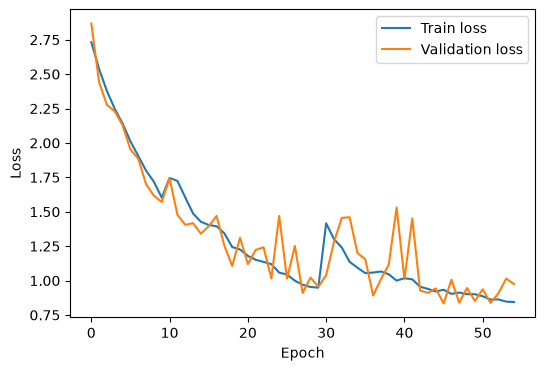

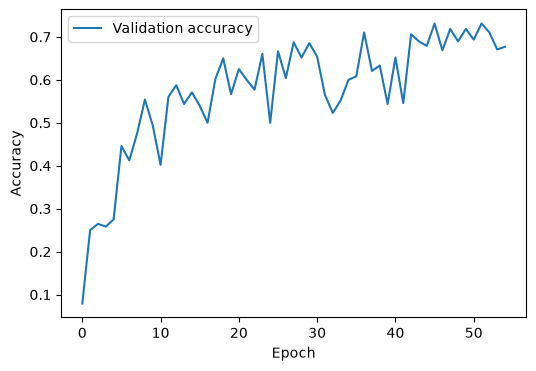

In [39]:
# Plot the starter training history.
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 6. Your turn: beat the baseline

This simple model should only be treated as a sanity check. The objective is to substantially improve its performance.

Rather than asking an AI tool to "make the accuracy higher," I formulated hypotheses about possible limitations of the model and tested them experimentally. Examples of the questions I considered included whether the model was overfitting, whether color information mattered, whether stronger augmentation would help, whether a different CNN architecture would be more appropriate, whether pretrained CNN features would transfer well, and whether optimization or regularization was limiting performance.

For each important experiment, I recorded what I changed, why I changed it, and what I learned from the results.

| Experiment | What changed? | Why did you try it? | Validation accuracy | What did you learn? |
|---|---|---|---:|---|
| Baseline | Starter TNet | Sanity check | .479 | -- |
| Experiment 1 | Added CNN layers in groups of three consisting of convolution, ReLU, and MaxPool layers. | I wanted to explore how increasing the model's depth affected performance and determine the practical parameter limits of my GPU. | 0.35 | I learned that simply increasing the depth of the architecture was not sufficient. I needed to reconsider the architecture and introduce data augmentation to help the model learn more robust features. |
| Experiment 2 | Used transformations from the [PyTorch transforms documentation](https://docs.pytorch.org/vision/stable/transforms.html) and randomly applied several augmentations. | I wanted to determine whether data augmentation could improve the performance of my poorly performing model. | 0.050 | The model converged to a point where it stopped learning effectively. In particular, applying transformations such as Gaussian blur may have made the task unnecessarily difficult. I learned that augmentations need to be selected carefully rather than added randomly. |
| Experiment 3 | Reversed the progression of the number of filters so that the number of filters increased as the network became deeper. | I wanted to test the opposite of my initial architectural intuition and determine whether increasing the number of filters through the network would work better. | 0.406 | I learned that additional epochs improved performance but also increased overfitting. The model may have been too large for the amount of training data available, suggesting that I needed to reduce its size. |
| Experiment 4 | Tuned several hyperparameters and modified some of the augmentations. | I wanted to determine whether the task was too easy or whether changes to the hyperparameters and augmentations could improve performance. | 0.45 | I believed the model was overfitting and that some of my previous changes were moving in the wrong direction. |
| Experiment 5 | Added padding to preserve more spatial information after convolution operations. | I wanted to reduce the loss of spatial information as the image passed through the network and preserve more local features. | 0.4979 | Both training and validation accuracy increased. I concluded that additional augmentation could help the model generalize better, but I also learned that augmentations should be introduced gradually rather than all at once. |
| Experiment 6 | Added Batch Normalization. | I wanted to normalize the activations within the network and determine whether this would improve training stability and performance. | 0.6062 | Batch Normalization improved validation accuracy, although overfitting was still present. I decided to increase the difficulty of the training problem again. |
| Experiment 7 | Iteratively reduced the size of the model by changing the number of filters and channels. | I wanted to reduce overfitting by decreasing the number of parameters in the model. | 0.53 | I learned that model capacity needs to be balanced with the amount of available training data. Reducing the model gradually allowed me to evaluate the effects of each architectural change rather than making a large change all at once. |
| Experiment 8 | Added a variable learning rate that decreases after the model stalls for a specified number of epochs. | I noticed that the learning rate appeared to be too high at certain points during training. I wanted to allow the model to make larger updates initially while reducing the learning rate when progress stalled. | 0.5896 | I learned that the initial learning rate may have been too high. Validation performance improved as the learning rate decreased. The lower learning rate also appeared to reduce the amount of overfitting compared with some of my earlier experiments. |
| Experiment 9 | Changed the augmentations so that their difficulty increased depending on the training epoch. | I hypothesized that the training examples were too difficult early in training and too easy later in training. I wanted to introduce progressively more difficult examples as the model learned. | 0.6062 | I found that progressively increasing augmentation difficulty was promising. However, the augmentation schedule still needed to be tuned so that the training did not begin too easily or become unnecessarily difficult. I also needed to modify the learning-rate scheduler so that the learning rate did not decrease too quickly as the training difficulty changed. |
| Experiment 10 and 11 | Modified the neural network to use adaptive pooling, changed the network layers, and increased the input image size. | I had reached a performance plateau with the previous image size. I initially expected increasing the image size to significantly increase the number of parameters, but adaptive average pooling provided a way to increase the image resolution without creating a very large fully connected layer. | 0.7146 | I learned that adaptive pooling can prevent a large increase in the number of parameters when increasing image resolution. I also found that adding additional layers allowed the model to learn more complex features without causing as much overfitting as some of my earlier, larger architectures. |
| Experiment 12 | Correctly separated the training and validation transformations. | I realized that the validation dataset was undergoing the same augmentations as the training dataset. This was inappropriate because the validation set should provide a consistent measurement of performance on realistic inputs. | 0.6729 | Although the validation accuracy decreased, the new validation measurement provided a more realistic indication of generalization. My previous validation accuracy had been affected by applying training augmentations to the validation data. |
| Experiment 13 | Tested stacking additional convolutional layers. | I wanted to determine whether chaining additional convolutional layers could improve feature extraction without requiring a major architectural change. | 0.749 | Validation accuracy improved substantially with a relatively small architectural change. However, the results were less predictable between runs, suggesting that this approach warranted further investigation. |
| Experiment 14 | Added a fourth augmentation stage. | Previous increases in augmentation difficulty had improved performance, so I wanted to determine whether adding another stage would provide additional benefits. | 0.700 | I learned that additional augmentation stages need to introduce useful new variations rather than simply making the images more distorted. Designing increasingly difficult but still meaningful training examples is more challenging than simply adding more transformations. |
| Final Model | Imported ResNet, modified the first convolutional layer to accept grayscale images, and fine-tuned a pretrained ResNet. | I tested one of the approaches suggested in the assignment materials: using a pretrained CNN architecture. | 1.0 | The pretrained ResNet achieved substantially higher validation accuracy than my custom CNN experiments. This demonstrated the potential value of pretrained feature representations for this task. It also suggested that the trained ResNet could potentially serve as a strong teacher model for knowledge distillation. |

**Do not use the test set to choose among these experiments.**

In [653]:
# FINAL TEST EVALUATION CNN with augmentation Layers
# Run this only after you have selected your final model using validation results.
# Replace `model` with your final selected model/checkpoint.

test_loss, test_acc = evaluate(model, test_loader, device)
print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_acc:.4f}')

Final test loss: 0.8642
Final test accuracy: 0.7125


In [11]:
# FINAL TEST EVALUATION for ResNet
# Run this only after you have selected your final model using validation results.
# Replace `model` with your final selected model/checkpoint.

test_loss, test_acc = evaluate(teacher, test_loader, device)
print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_acc:.4f}')

NameError: name 'evaluate' is not defined

## 7. AI-assisted development checkpoint

Before submission, create `AI_USAGE.md` in your GitHub repository. You do **not** need to provide every prompt. Include:

1. the AI coding tool(s) you used;
2. 3--5 representative ways AI assisted you;
3. at least one AI suggestion that was incorrect, ineffective, or questionable;
4. how you tested, verified, corrected, or rejected that suggestion; and
5. one important architecture/experimental decision that **you** made.

A good entry describes the engineering/research interaction rather than saying only, ``I used ChatGPT to write code.''

### A useful habit
When AI generates code, ask yourself before running it:
- What do I expect this code to do?
- What assumption is it making about tensor shape/data/model behavior?
- How will I know if it is wrong?
- What experiment would distinguish a real improvement from noise?

## 8. GitHub and submission requirements

All assignment code must be maintained in **GitHub** (not GitLab). Your repository should contain a meaningful commit history and, at minimum:

```text
README.md
AI_USAGE.md
training / model code
inference or evaluation code
requirements.txt or environment information
final checkpoint or a link to it
reproduction instructions
```

Do not create the entire repository as a single commit immediately before the deadline. Use Git throughout development as you would in a real research or engineering project.

Your final submission is a **maximum two-page PDF report** containing the working GitHub link. The report should clearly state your best result, validation/model-selection strategy, final recipe, important experiments, at least one failure analysis, and a brief AI+human reflection.

Friendly discussion and brainstorming are encouraged, but your implementation, experiments, report, and repository must be your own. Do not share code, checkpoints, detailed hyperparameters, or test predictions before the deadline.

The instructor may ask you to explain any important component of your submitted system. You are responsible for understanding all code in your final repository, including AI-generated code.

**Deadline: September 25, 2026 at 11:59 PM EDT.**

Good luck — and treat this as your first small computer vision research project of the semester.